In [18]:
## Import packages

# General purpose modules
import time
from copy import deepcopy
import warnings

# Data handling and visualization modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cupy as cp

# Skikit-learn preprocessing and evaluation modules
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import roc_auc_score

# Skikit-learn ML modules
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression

# Further ML modules
import xgboost as xgboost
import lightgbm as lightgbm
#from catboost import CatBoostClassifier

In [19]:
## Read csv files and spliting the data into training and validation set

ADD_EXTERN_DATA = False # Extend dataset with external data
STRAT = False # Use stratification for data spliting
EXTENDED_STRAT = False # Stratification is based on multiple features

# Read csv files
trainval = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
#extern_data = pd.read_csv('/kaggle/input/heartdisease/Heart_Disease_Prediction.csv')
if ADD_EXTERN_DATA:
    trainval = pd.concat([trainval[trainval.columns[1:]], extern_data[trainval.columns[1:]]]
                         ).reset_index(drop=True).reset_index().rename(columns={'index':'id'})

# Discretization of labels and numeric features
target = 'Heart Disease'
trainval[target] = LabelEncoder().fit_transform(trainval[target]).astype(np.uint8)

# Calculate statistical features for all columns
global_stats = {'mean': trainval[target].mean(), 'median': trainval[target].median(), 'count': 0}
freq_encodings = {}
stats_mean = {}
stats_median = {}
stats_count = {}
for c in trainval.columns[1:-1]:
    freq_encodings[c] = trainval[c].value_counts(normalize=True).to_dict()
    for stat in ['mean', 'median', 'count']:
        globals()['stats_' + stat][c] = trainval.groupby(c)[target].agg([stat]).to_dict()[stat]

# Determine stratification bins
strat_encoder = LabelEncoder()
strat_encoder_eval = LabelEncoder()
strat_cols = ['Thallium', 'Chest pain type', target]
strat_cols_eval = ['Thallium', 'Chest pain type', 'Number of vessels fluro']
trainval['multicat'] = strat_encoder.fit_transform(trainval[strat_cols].astype(str).agg('_'.join, axis=1))
trainval['multicat_eval'] = strat_encoder_eval.fit_transform(trainval[strat_cols_eval].astype(str).agg('_'.join, axis=1))
sss = (StratifiedShuffleSplit if STRAT else ShuffleSplit)(n_splits=1, test_size=0.01, random_state=42)

# Spliting data
train_idx, val_idx = next(sss.split(trainval, trainval['multicat'] if EXTENDED_STRAT else trainval[target]))
train = trainval.iloc[train_idx].reset_index()
val = trainval.iloc[val_idx].reset_index()
trainval_labels = trainval.pop(target)
train_labels = train.pop(target)
val_labels = val.pop(target)

# Verify sizes
print(f"Total rows:   {len(trainval)}")
print(f"Dev train:    {len(train)} ({len(train)/len(trainval):.2%})")
print(f"Dev valid:    {len(val)} ({len(val)/len(trainval):.2%})")
print(f"Number of unique elements in multicat column: {len(trainval['multicat'].unique())}")
print('-'*80, end='\n\n')

# Size of stratification bins
print(trainval['multicat'].value_counts().tail())
print('-'*80, end='\n\n')
print(trainval['multicat_eval'].value_counts().tail())

Total rows:   630000
Dev train:    623700 (99.00%)
Dev valid:    6300 (1.00%)
Number of unique elements in multicat column: 24
--------------------------------------------------------------------------------

multicat
1     930
10    547
11    327
8     222
9      65
Name: count, dtype: int64
--------------------------------------------------------------------------------

multicat_eval
22    59
17    36
23    25
18    15
19     5
Name: count, dtype: int64


List of dataset columns including data types and number of non-zero elements: 

<class 'pandas.DataFrame'>
RangeIndex: 623700 entries, 0 to 623699
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   index                    623700 non-null  int64  
 1   id                       623700 non-null  int64  
 2   Age                      623700 non-null  int64  
 3   Sex                      623700 non-null  int64  
 4   Chest pain type          623700 non-null  int64  
 5   BP                       623700 non-null  int64  
 6   Cholesterol              623700 non-null  int64  
 7   FBS over 120             623700 non-null  int64  
 8   EKG results              623700 non-null  int64  
 9   Max HR                   623700 non-null  int64  
 10  Exercise angina          623700 non-null  int64  
 11  ST depression            623700 non-null  float64
 12  Slope of ST              623700 non-null  int

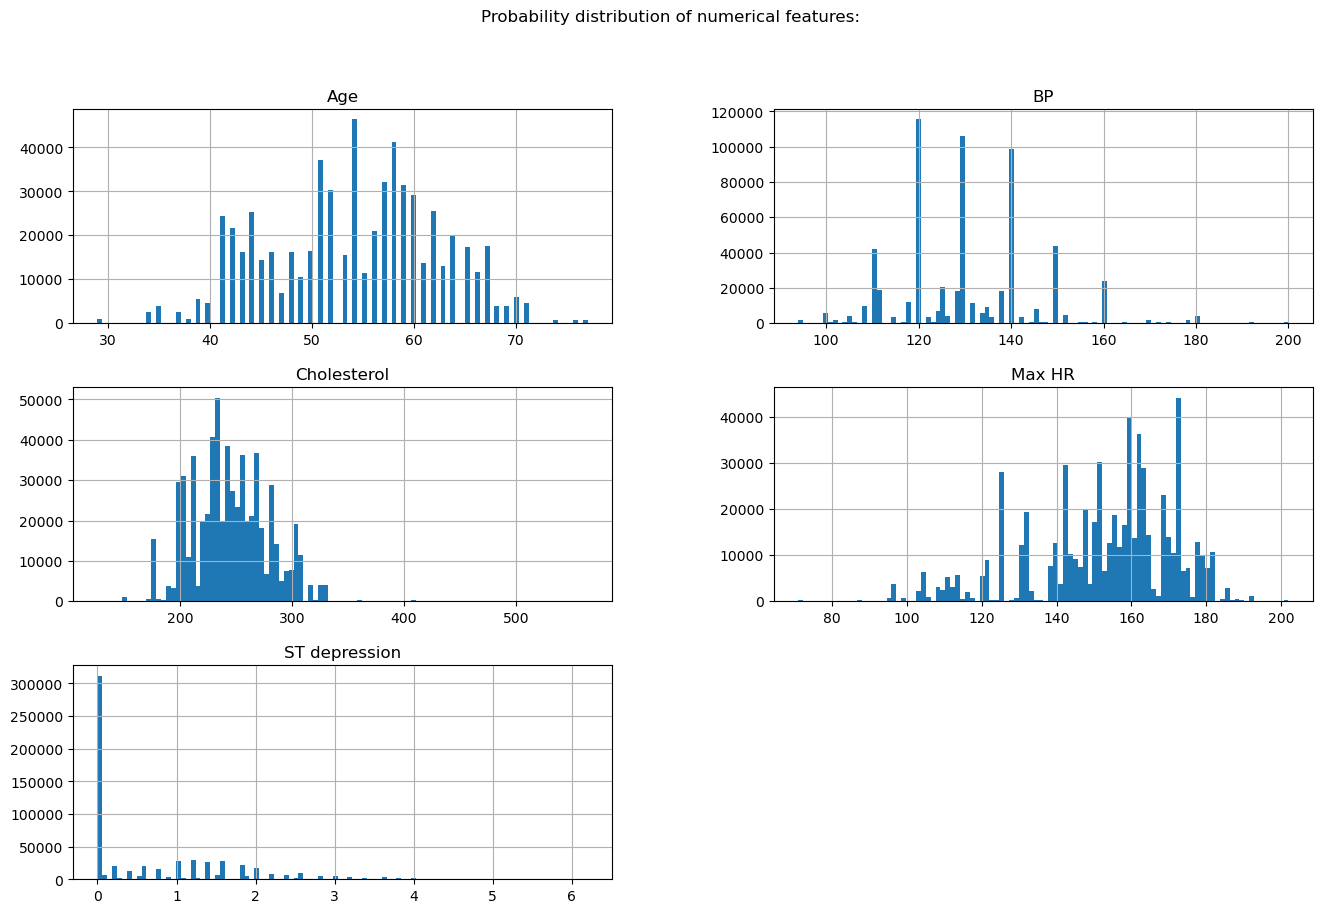

In [20]:
## Explore train dataset

print('List of dataset columns including data types and number of non-zero elements: ', end='\n\n')
train.info()
print('-'*80, end='\n\n')

# Explore categorical features
cat_columns = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST',
              'Number of vessels fluro', 'Thallium']
print('Number of unique elements of categorical features: ', end='\n\n')
for cat in cat_columns:
    print(train[cat].value_counts(), end='\n\n')

# Explore numerical features
num_columns = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
train[num_columns].hist(bins=100, figsize=(16,10))
plt.suptitle('Probability distribution of numerical features: ')
print('-'*80, end='\n\n')

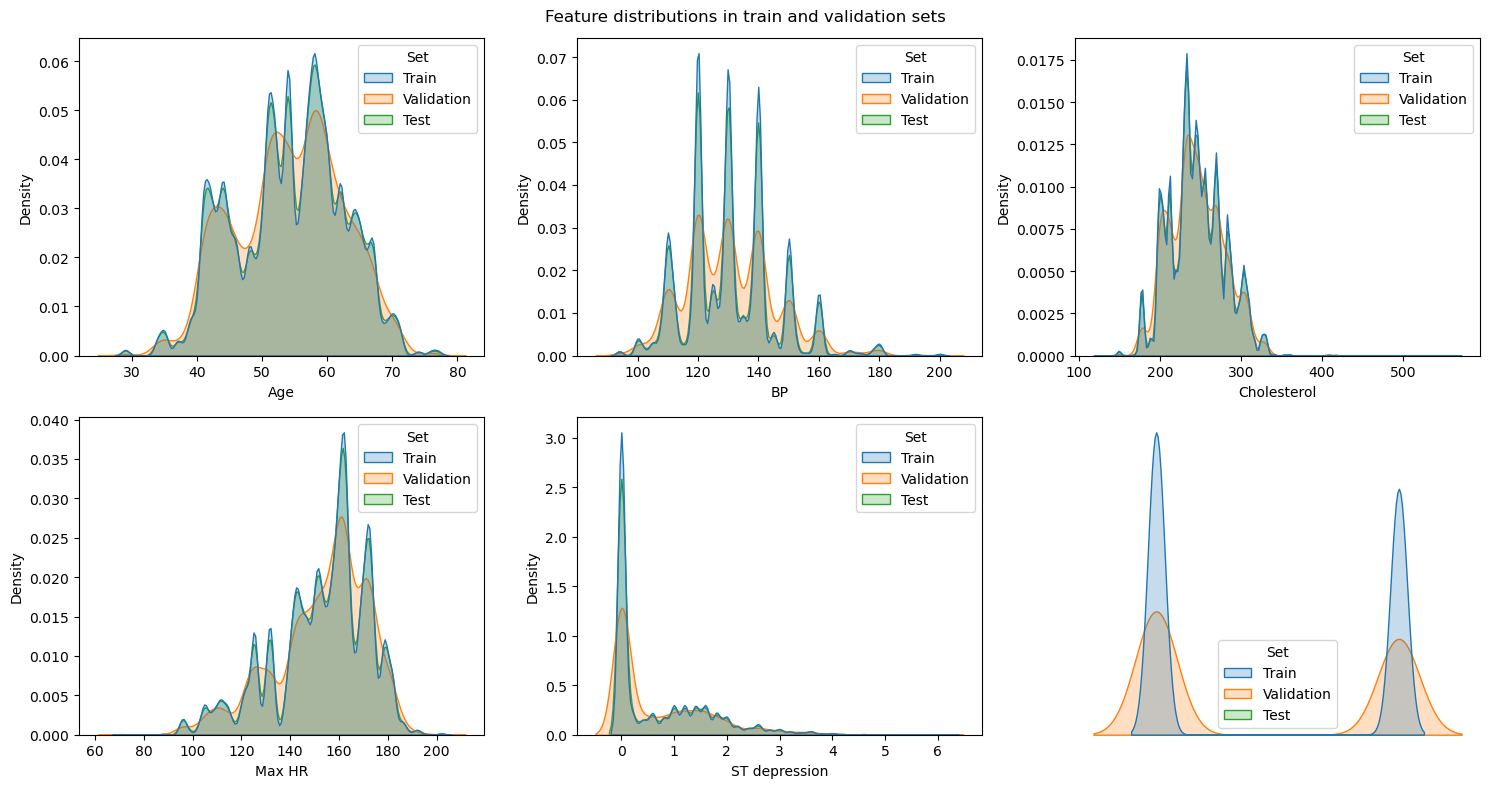

In [21]:
## Compare probabilty distribution of numerical features between train, validation and test sets

df_plot = pd.concat([train[num_columns].assign(Set='Train'), val[num_columns].assign(Set='Validation'),
                     test[num_columns].assign(Set='Test')])
df_plot.insert(5, value=pd.concat([train_labels, val_labels, pd.Series([None] * len(test), name=target)]), column=target)
df_plot.reset_index(drop=True, inplace=True)
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn") # Suppress the specific FutureWarning

n_cols = 3
n_rows = (len(num_columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
fig.suptitle('Feature distributions in train and validation sets')
axes = axes.flatten()
for i in range(len(num_columns), len(axes)):
    axes[i].axis('off')
for i, col in enumerate(df_plot.columns[:-1]):
    sns.kdeplot(data=df_plot, x=col, ax=axes[i], hue='Set', common_norm=False, fill=True)
plt.tight_layout()
plt.show()
del df_plot

In [22]:
## Helping functions for adding statistical features

def frq_enc(X, features, freq_encodings=freq_encodings):
    X_freq = pd.DataFrame()
    for c in features:
        X_freq[c] = X[c].map(freq_encodings[c]).astype(float).fillna(0)
    return X_freq

def target_stats(X, features, st_type, global_stats=global_stats):
    stats = globals()['stats_' + st_type]
    X_stat = pd.DataFrame()
    for c in features:
        X_stat[c] = X[c].map(stats[c]).fillna(global_stats[st_type])
    return X_stat

In [ ]:
## Define and fit preprocessing pipeline

robust_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                            ('robust_scaling', RobustScaler())])
ordinal_pipeline = Pipeline([('imputer', SimpleImputer(strategy="most_frequent")),
                             ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.int8))])
onehot_pipeline = Pipeline([('imputer', SimpleImputer(strategy="most_frequent")),
                            ('onehot', OneHotEncoder(sparse_output=False))])
log_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                         ('log_trans', FunctionTransformer(func=lambda x: np.log(x+0.001), feature_names_out='one-to-one')),
                         ('robust_scaling', RobustScaler())])
square_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                            ('square_trans', FunctionTransformer(func=np.square, feature_names_out='one-to-one')),
                            ('robust_scaling', RobustScaler())])
cube_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                          ('cube_trans', FunctionTransformer(func=lambda x: np.power(x, 3), feature_names_out='one-to-one')),
                          ('robust_scaling', RobustScaler())])
sqrt_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                          ('sqrt_trans', FunctionTransformer(func=np.sqrt, feature_names_out='one-to-one')),
                          ('robust_scaling', RobustScaler())])
cbrt_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                          ('cbrt_trans', FunctionTransformer(func=np.cbrt, feature_names_out='one-to-one')),
                          ('robust_scaling', RobustScaler())])
kbins_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                           ('kbins', KBinsDiscretizer(n_bins=10, strategy='uniform', encode='ordinal', random_state=42)),
                           ('kbins_cast', FunctionTransformer(lambda X: X.astype(np.uint8), feature_names_out='one-to-one'))])
frq_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                         ('frq', FunctionTransformer(func=lambda x: frq_enc(x, x.columns), feature_names_out='one-to-one'))])
mean_pipeline = Pipeline([('mean', FunctionTransformer(func=lambda x: target_stats(x, x.columns, 'mean'), feature_names_out='one-to-one'))])
median_pipeline = Pipeline([('median', FunctionTransformer(func=lambda x: target_stats(x, x.columns, 'median'), feature_names_out='one-to-one'))])
count_pipeline = Pipeline([('count', FunctionTransformer(func=lambda x: target_stats(x, x.columns, 'count'), feature_names_out='one-to-one'))])

# Preprocessing pipeline
nonlinear_transformer = ColumnTransformer([("scaled", robust_pipeline, num_columns),
                                           ("log", log_pipeline, num_columns),
                                           ("square", square_pipeline, num_columns),
                                           ("cube", cube_pipeline, num_columns),
                                           ("sqrt", log_pipeline, num_columns),
                                           ("cbrt", square_pipeline, num_columns)])
pca_pipeline = Pipeline([('nonlinear', nonlinear_transformer), ('pca', PCA(random_state=42))])

preprocessing = ColumnTransformer([("scaled", robust_pipeline, num_columns),
                                   #("pca", pca_pipeline, num_columns),
                                   ("cluster", kbins_pipeline, num_columns),
                                   ("frqn", frq_pipeline, num_columns),
                                   ("ordinal", ordinal_pipeline, cat_columns),
                                   ("frqc", frq_pipeline, cat_columns),
                                   ("mean", mean_pipeline, num_columns+cat_columns),
                                   ("median", median_pipeline, num_columns+cat_columns),
                                   ("count", count_pipeline, num_columns+cat_columns)]).set_output(transform='pandas')

# Preprocess data
train_prepared = preprocessing.fit_transform(train)
val_prepared = preprocessing.transform(val)
print(f'Number of unfiltered features: {train_prepared.shape[1]}')